## tl;dr

This notebook creates a reproducible mock DataFrame with 500 paired observations. `feature_x` has mean -0.013 and standard deviation 0.960; `feature_y` has mean -0.042 and standard deviation 0.990. The observed correlation is 0.624, so the scatter plot shows a clear positive relationship while both axes stay approximately normal.

## Context & Methods

The dataset is synthetic and generated locally. A fixed random seed makes the results reproducible.

### Key Assumptions

- `feature_x` is sampled from a standard normal distribution.
- `feature_y` is built as a correlated normal variable so both axes remain approximately normal.
- A scatter plot is appropriate because each row represents one paired observation.

## Data

### 1. Set Up Imports and Parameters

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
ROW_COUNT = 500
TARGET_CORRELATION = 0.65

rng = np.random.default_rng(RANDOM_SEED)

### 2. Generate a Mock Normal DataFrame

In [10]:
feature_x = rng.normal(loc=0, scale=1, size=ROW_COUNT)
independent_noise = rng.normal(loc=0, scale=1, size=ROW_COUNT)
feature_y = (
    TARGET_CORRELATION * feature_x
    + np.sqrt(1 - TARGET_CORRELATION**2) * independent_noise
)

mock_df = pd.DataFrame(
    {
        "observation_id": np.arange(1, ROW_COUNT + 1),
        "feature_x": feature_x,
        "feature_y": feature_y,
    }
)

mock_df.head()

,observation_id,feature_x,feature_y
0,1,0.304717,1.234512
1,2,-1.039984,0.004292
2,3,0.750451,-0.058964
3,4,0.940565,-0.530437
4,5,-1.951035,-3.521020


### 3. Check Shape and Distribution Summary

In [11]:
summary = mock_df[["feature_x", "feature_y"]].agg(
    ["count", "mean", "std", "min", "median", "max", "skew"]
).T
summary["kurtosis"] = mock_df[["feature_x", "feature_y"]].kurtosis()
summary["correlation_to_other_axis"] = [
    mock_df["feature_x"].corr(mock_df["feature_y"]),
    mock_df["feature_y"].corr(mock_df["feature_x"]),
]

summary.round(3)

,count,mean,std,min,median,max,skew,kurtosis,correlation_to_other_axis
feature_x,500.0,-0.013,0.96,-2.567,0.003,2.914,0.094,-0.040,0.624
feature_y,500.0,-0.042,0.99,-3.521,0.015,2.837,-0.164,-0.173,0.624


## Results

### 4. Scatter Plot

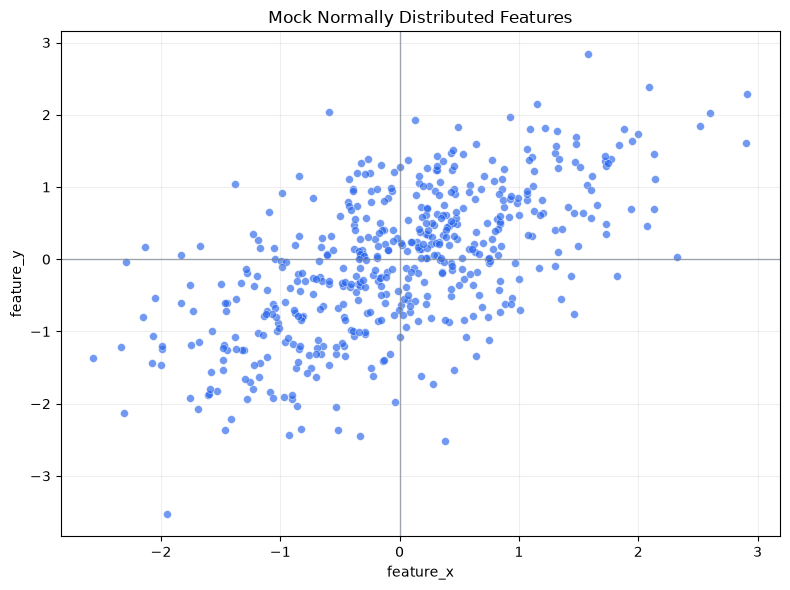

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    mock_df["feature_x"],
    mock_df["feature_y"],
    alpha=0.65,
    s=32,
    color="#2563eb",
    edgecolors="white",
    linewidths=0.4,
)
ax.axhline(0, color="#6b7280", linewidth=1, alpha=0.6)
ax.axvline(0, color="#6b7280", linewidth=1, alpha=0.6)
ax.set_title("Mock Normally Distributed Features")
ax.set_xlabel("feature_x")
ax.set_ylabel("feature_y")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Takeaways

- The generated DataFrame contains 500 paired observations.
- Both plotted variables are centered close to 0 with standard deviations close to 1: `feature_x` mean -0.013, std 0.960; `feature_y` mean -0.042, std 0.990.
- The realized correlation is 0.624, close to the target correlation of 0.65, and the scatter plot shows the intended positive relationship.